In [9]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import re
from tqdm import tqdm

%load_ext autoreload
%autoreload 2

from utils import load_excel_sheets, process_benchmark_stats, aggregate_stats, global_model_list

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
dfs = load_excel_sheets('../data/MM/P1')

print("\nLoaded dataframe keys:", list(dfs.keys()))

 Loaded: ChatGPT-4o_d.xlsx Sheets:[3/3]
 Loaded: Gemini 3.0_d.xlsx Sheets:[3/3]
 Loaded: Gemini 2.5_d.xlsx Sheets:[3/3]
 Loaded: ChatGPT-5.1_d.xlsx Sheets:[3/3]

Loaded dataframe keys: ['P1_ChatGPT-4o_CM', 'P1_ChatGPT-4o_EM', 'P1_ChatGPT-4o_QM', 'P1_Gemini 3.0_CM', 'P1_Gemini 3.0_EM', 'P1_Gemini 3.0_QM', 'P1_Gemini 2.5_CM', 'P1_Gemini 2.5_EM', 'P1_Gemini 2.5_QM', 'P1_ChatGPT-5.1_CM', 'P1_ChatGPT-5.1_EM', 'P1_ChatGPT-5.1_QM']


In [11]:
process_benchmark_stats(dfs)
# Verify the result with the first dataframe
if dfs:
    first_key = list(dfs.keys())[0]
    print(f"\nFirst 5 rows of {first_key}:")
    display(dfs[first_key].head())

Processing DataFrames: 100%|██████████| 12/12 [00:00<00:00, 726.97it/s]


First 5 rows of P1_ChatGPT-4o_CM:


,Question Number,Available Marks,Solution 1,Solution 2,Solution 3,Dir,Model,Sheet,key,mean solution,std solution,mean percentage mark,std percentage
0,1,5,4,5,3,P1,ChatGPT-4o,CM,P1_ChatGPT-4o_CM,4.000000,1.000000,80.000000,20.000000
1,2,6,6,1,1,P1,ChatGPT-4o,CM,P1_ChatGPT-4o_CM,2.666667,2.886751,44.444444,48.112522
2,3,9,9,9,9,P1,ChatGPT-4o,CM,P1_ChatGPT-4o_CM,9.000000,0.000000,100.000000,0.000000
3,4,10,10,10,10,P1,ChatGPT-4o,CM,P1_ChatGPT-4o_CM,10.000000,0.000000,100.000000,0.000000
4,5,10,8,5,7,P1,ChatGPT-4o,CM,P1_ChatGPT-4o_CM,6.666667,1.527525,66.666667,15.275252


In [12]:
# Create master df and summary df for plotting
master_df, summary_stats = aggregate_stats(dfs)

display(master_df.head())
display(summary_stats.head())

/Users/jonah/Github - Projects/LLM Project paper/AI-in-Physics-in-Education-j/Plot code/utils.py:128: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_stats = master_df.groupby(['Dir', 'Model', 'Sheet']).agg(


,Question Number,Available Marks,Solution 1,Solution 2,Solution 3,Dir,Model,Sheet,key,mean solution,std solution,mean percentage mark,std percentage
0,1,5,4.0,5,3.0,P1,ChatGPT-4o,CM,P1_ChatGPT-4o_CM,4.000000,1.000000,80.000000,20.000000
1,2,6,6.0,1,1.0,P1,ChatGPT-4o,CM,P1_ChatGPT-4o_CM,2.666667,2.886751,44.444444,48.112522
2,3,9,9.0,9,9.0,P1,ChatGPT-4o,CM,P1_ChatGPT-4o_CM,9.000000,0.000000,100.000000,0.000000
3,4,10,10.0,10,10.0,P1,ChatGPT-4o,CM,P1_ChatGPT-4o_CM,10.000000,0.000000,100.000000,0.000000
4,5,10,8.0,5,7.0,P1,ChatGPT-4o,CM,P1_ChatGPT-4o_CM,6.666667,1.527525,66.666667,15.275252


,Dir,Model,Sheet,Total_Mean%,Total_Std,Total_Std_error%
0,P1,ChatGPT-4o,CM,80.833333,23.591168,10.550291
1,P1,ChatGPT-4o,EM,87.387387,18.149093,8.116521
2,P1,ChatGPT-4o,QM,81.481481,17.142935,7.666554
3,P1,Gemini 2.5,CM,82.500000,17.061979,7.630349
4,P1,Gemini 2.5,EM,94.594595,11.180340,5.000000


,Dir,Model,Sheet,Total_Mean%,Total_Std,Total_Std_error%
0,P1,ChatGPT-4o,CM,80.833333,23.591168,10.550291
3,P1,Gemini 2.5,CM,82.500000,17.061979,7.630349
6,P1,ChatGPT-5.1,CM,95.833333,8.366600,3.741657
9,P1,Gemini 3.0,CM,100.000000,0.000000,0.000000


Dirs: ['P1']
Sheets: ['CM' 'EM' 'QM']


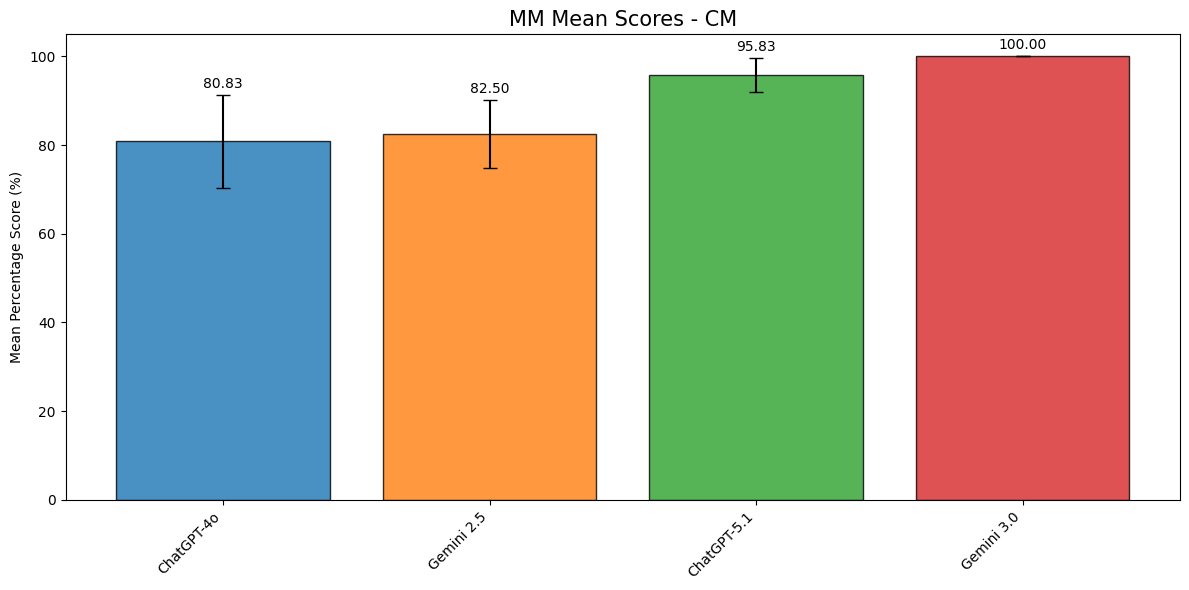

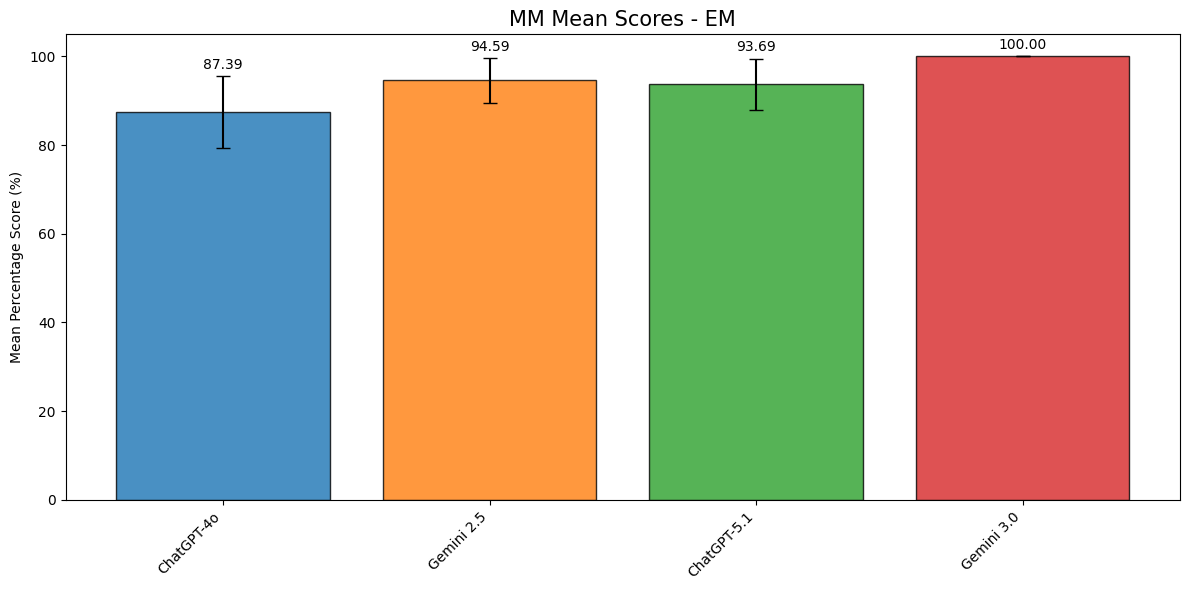

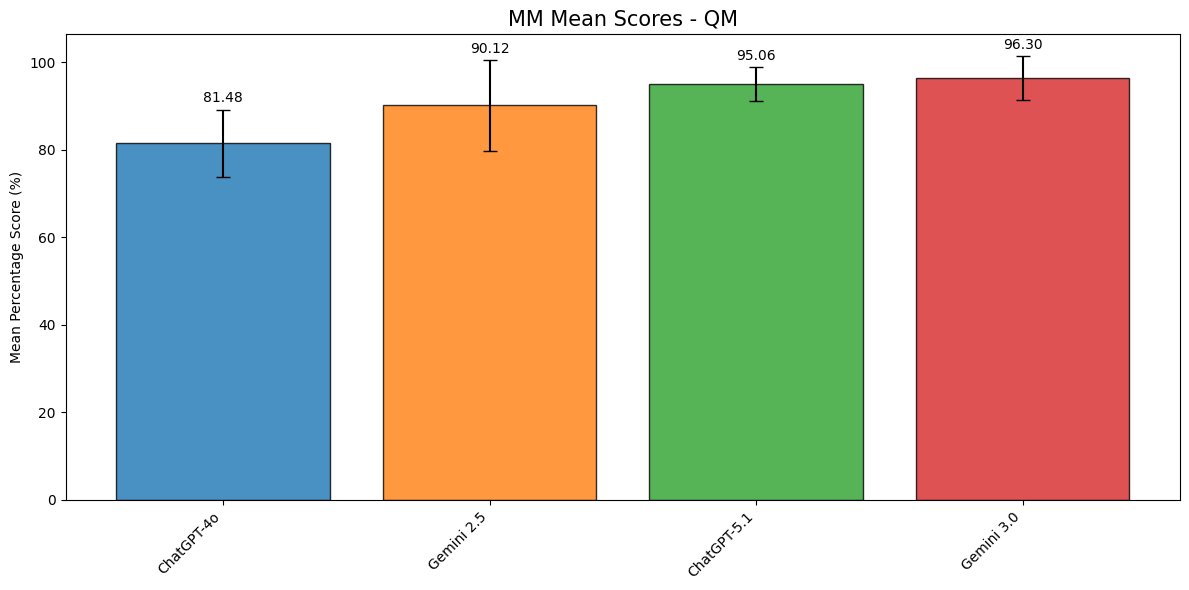

In [13]:
# Get relevant models
unique_models = master_df['Model'].unique()
model_list = [model for model in global_model_list if model in unique_models]
topic_sheet_df = summary_stats.groupby(['Dir','Sheet'])

display(topic_sheet_df.get_group(('P1', 'CM')))

# Get unique dirs and sheets for plotting
dir_list = master_df['Dir'].unique()
sheet_list = master_df['Sheet'].unique()

print("Dirs:", dir_list)
print("Sheets:", sheet_list)

# Colors
colors = ["#1b75b5", '#ff7f0e', '#2ca02c', '#d62728', "#7b46ad", '#8c564b']

safe_colors = (colors * 3) 

for dir in dir_list:
    for sheet in sheet_list:
        # Extract data
        try:
            group = topic_sheet_df.get_group((dir, sheet))
        except KeyError:
            continue # Skip completely if this Dir/Sheet combo doesn't exist
            
        group = group.dropna(subset=['Total_Mean%'])
        
        # If dropping the missing models leaves the group completely empty, skip plotting
        if group.empty:
            continue

        # 1. Grab the exact models and stats present in THIS specific group
        current_models = group['Model']
        means = group['Total_Mean%']
        std_errs = group['Total_Std_error%']

        fig, ax = plt.subplots(figsize=(12, 6))

        # 2. Set X to match the actual number of rows left in the group
        x = np.arange(len(current_models)) 
        
        # 3. Slice the colors to match the exact number of bars
        current_colors = safe_colors[:len(x)]
        
        # Plotting
        rects1 = ax.bar(x, means, width=0.8, yerr=std_errs, 
                        capsize=5, color=current_colors, edgecolor='black', alpha=0.8)

        ax.set_ylabel('Mean Percentage Score (%)')
        ax.set_title(f'MM Mean Scores - {sheet}', fontsize=15)
        ax.set_xticks(x)
        
        # 4. Use the current_models for the labels so they align perfectly
        ax.set_xticklabels(current_models, rotation=45, ha='right')

        # Add labels 
        ax.bar_label(rects1, padding=3, fmt='%.2f')

        # Save figure
        output_dir = '../Plots/Bar_Charts'
        os.makedirs(output_dir, exist_ok=True)
        plt.savefig(os.path.join(output_dir, f'MM_{sheet}_Bar_Chart.png'), dpi=300, bbox_inches='tight')

        plt.tight_layout()
        plt.show()

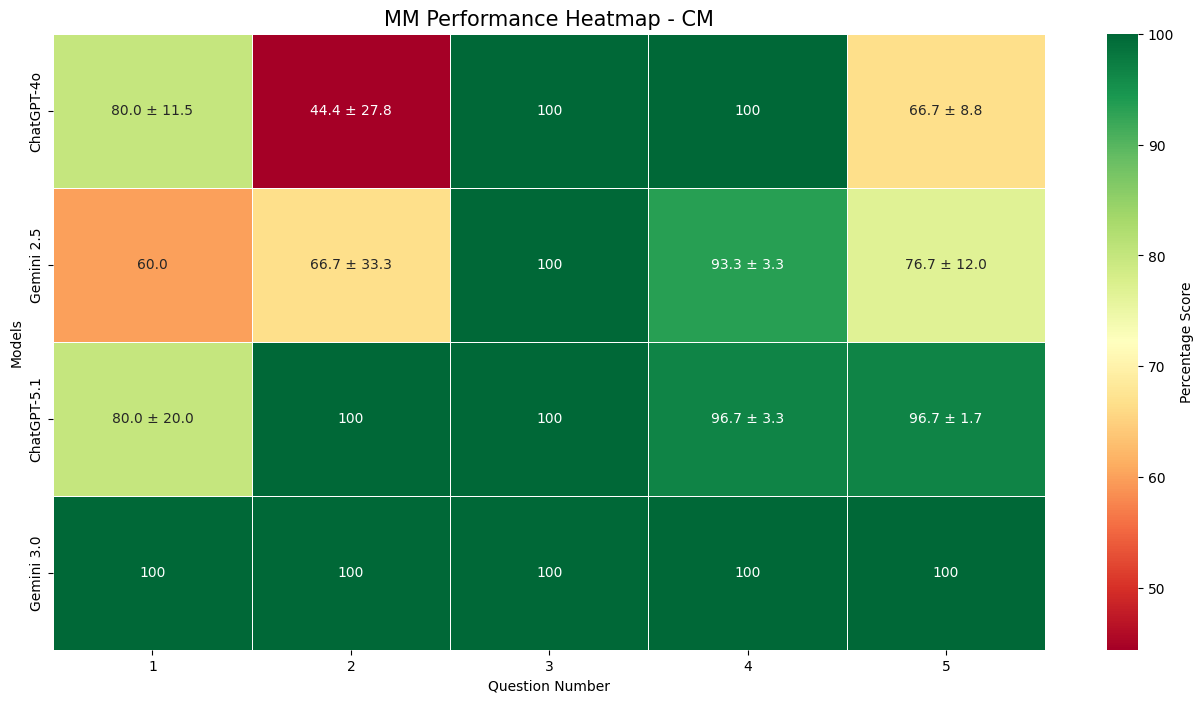

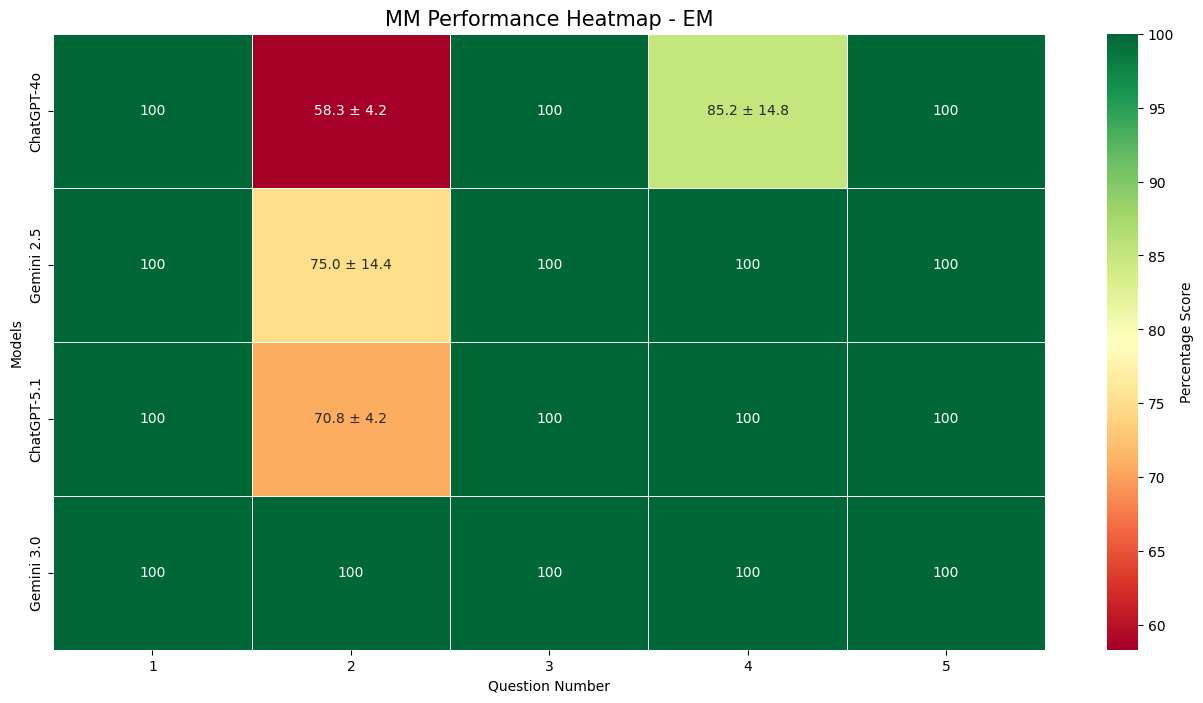

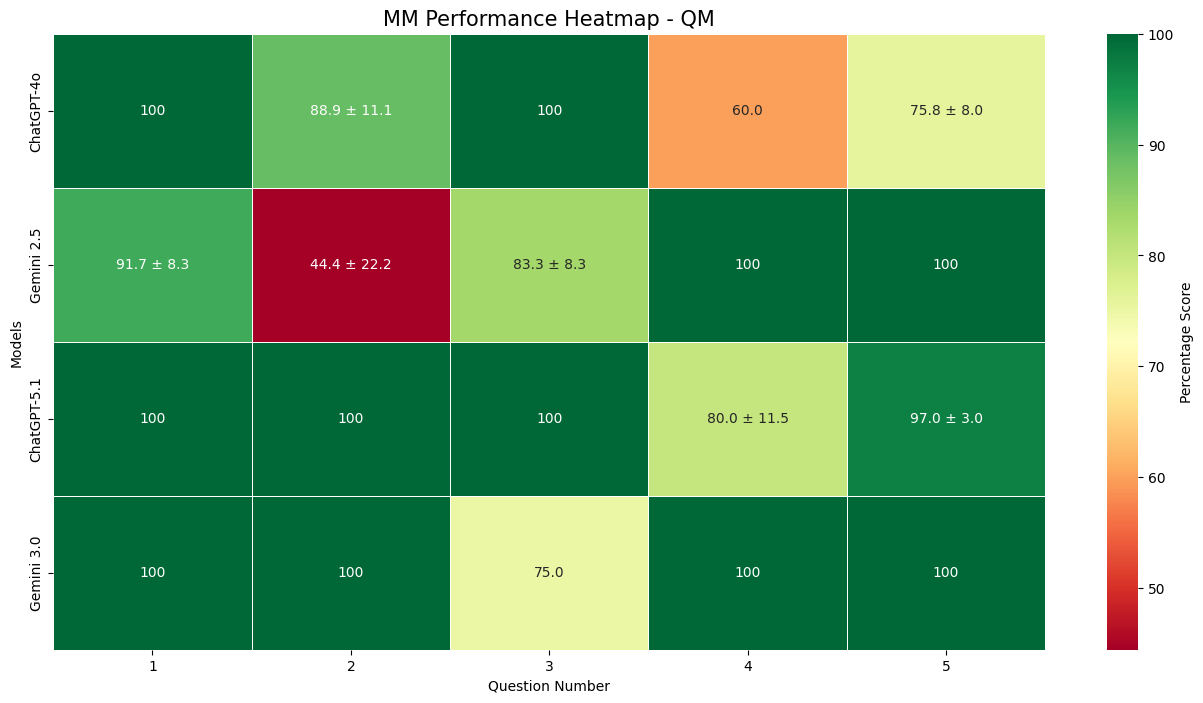

In [14]:
# Heat map
# Rows - Models
# Cols - Questions

master_df['Model'] = pd.Categorical(master_df['Model'], categories=model_list, ordered=True)
master_df = master_df.sort_values(['Dir', 'Model', 'Sheet', 'Question Number'])

topic_sheet_df = master_df.groupby(['Dir','Sheet'])

for dir in dir_list:
    for sheet in sheet_list:
        # Get the group
        try:
            target_group = topic_sheet_df.get_group((dir, sheet)).copy()
        except KeyError:
            continue

        # 1. Create the base matrices
        heatmap_matrix = target_group.pivot(index='Model', columns='Question Number', values='mean percentage mark')
        heatmap_matrix_std = target_group.pivot(index='Model', columns='Question Number', values='std percentage') 
        heatmap_matrix_se = heatmap_matrix_std / np.sqrt(3) 

        # 2. Build the custom annotation matrix
        annot_labels = np.empty(heatmap_matrix.shape, dtype=object)
        
        for i in range(heatmap_matrix.shape[0]):
            for j in range(heatmap_matrix.shape[1]):
                mean = heatmap_matrix.values[i, j]
                se = heatmap_matrix_se.values[i, j]
                
                # Handle missing data (NaN)
                if pd.isna(mean):
                    annot_labels[i, j] = ""
                    continue
                
                # Logic for "Mean ± SE" or simple "Mean"
                if round(se, 1) == 0.0:
                    # Clean look for 100% or 0% with no variance
                    if mean == 100.0 or mean == 0.0:
                        annot_labels[i, j] = f"{mean:.0f}" 
                    else:
                        annot_labels[i, j] = f"{mean:.1f}"
                else:
                    # Standard formatting
                    annot_labels[i, j] = f"{mean:.1f} ± {se:.1f}"

        # 3. Plotting
        plt.figure(figsize=(16, 8))
        sns.heatmap(heatmap_matrix, 
                    annot=annot_labels,    
                    fmt="",                # Must be empty string when using custom labels
                    cmap='RdYlGn',         
                    linewidths=0.5,        
                    cbar_kws={'label': 'Percentage Score'})

        plt.title(f'MM Performance Heatmap - {sheet}', fontsize=15)
        plt.ylabel('Models')
        plt.xlabel('Question Number')

        # Save figure
        output_dir = '../Plots/Heat_Maps'
        os.makedirs(output_dir, exist_ok=True)
        plt.savefig(os.path.join(output_dir, f'MM_{sheet}_Heat_Map.png'), dpi=300, bbox_inches='tight')
    
        plt.show()